# Hypothesis Testing Analysis of Network Traffic Attacks
## UNSW-NB15 Dataset

**Student:** MEKCI RAIHAN  
**Group:** B1  
**Module:** Probability and Statistics (PRST2)  
**Academic year:** 2025/2026

---

This notebook applies the methods of **Chapter 3 (Hypothesis Testing)** to the UNSW-NB15 testing set.
We test hypotheses about **means** (Student t-test and normal approximation), about **variances** (F-test),
and about **proportions/distributions** (chi-squared goodness-of-fit and homogeneity tests).

All decisions are taken at significance level **α = 0.05** using **critical values from the statistical tables**,
as required by the course.

## 1. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
ALPHA = 0.05

df = pd.read_csv('UNSW_NB15_testingset.csv')
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


## 2. Brief data exploration

In [2]:
print('Shape:', df.shape)
print('Missing values total:', df.isnull().sum().sum())
print()
print('Label counts (0 = Normal, 1 = Attack):')
print(df['label'].value_counts())
print()
print('Attack categories:')
print(df['attack_cat'].value_counts())

Shape: (82332, 45)
Missing values total: 0

Label counts (0 = Normal, 1 = Attack):
label
1    45332
0    37000
Name: count, dtype: int64

Attack categories:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


**Observations:**
- 82,332 records and 45 columns, no missing values.
- 45,332 attacks (55.06%) and 37,000 normal connections (44.94%).
- 9 attack categories, dominated by *Generic*, *Exploits*, *Fuzzers*, and *DoS*.

## 3. Visualisations

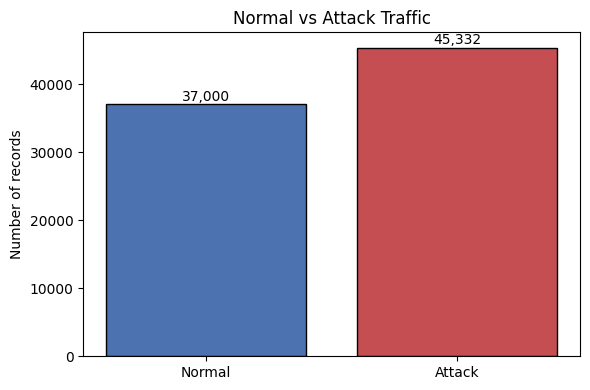

In [3]:
# Figure 1 — Normal vs Attack
counts = df['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Normal','Attack'], counts.values, color=['#4C72B0','#C44E52'], edgecolor='black')
ax.set_title('Normal vs Attack Traffic')
ax.set_ylabel('Number of records')
for i,c in enumerate(counts.values):
    ax.text(i, c+500, f'{c:,}', ha='center')
plt.tight_layout(); plt.show()

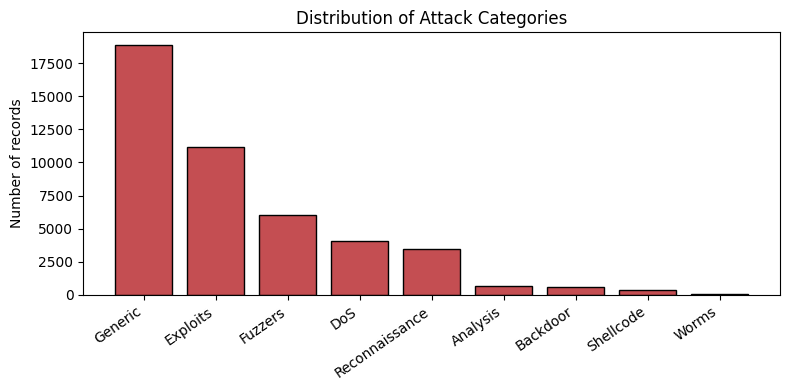

In [4]:
# Figure 2 — Attack categories
ac = df[df['label']==1]['attack_cat'].value_counts()
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(ac.index, ac.values, color='#C44E52', edgecolor='black')
ax.set_title('Distribution of Attack Categories')
ax.set_ylabel('Number of records')
plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

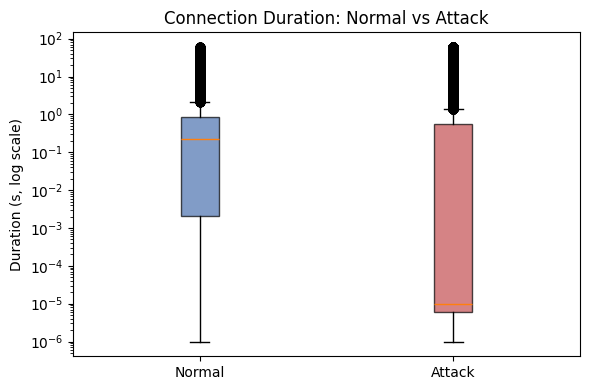

In [5]:
# Figure 3 — Duration boxplot (log scale)
data_box = [df[df['label']==0]['dur'].replace(0,1e-6),
            df[df['label']==1]['dur'].replace(0,1e-6)]
fig, ax = plt.subplots(figsize=(6,4))
bp = ax.boxplot(data_box, tick_labels=['Normal','Attack'], patch_artist=True)
for patch, c in zip(bp['boxes'], ['#4C72B0','#C44E52']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_yscale('log')
ax.set_title('Connection Duration: Normal vs Attack')
ax.set_ylabel('Duration (s, log scale)')
plt.tight_layout(); plt.show()

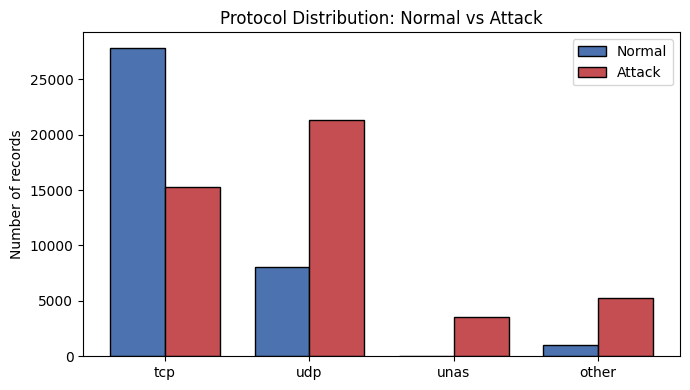

In [6]:
# Figure 4 — Protocol distribution Normal vs Attack
top_protos = df['proto'].value_counts().head(3).index.tolist()
df['proto_grp'] = df['proto'].apply(lambda x: x if x in top_protos else 'other')
ct = pd.crosstab(df['proto_grp'], df['label']).reindex(['tcp','udp','unas','other'])
x = np.arange(len(ct.index)); w = 0.38
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x-w/2, ct[0].values, w, label='Normal', color='#4C72B0', edgecolor='black')
ax.bar(x+w/2, ct[1].values, w, label='Attack', color='#C44E52', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(ct.index)
ax.set_title('Protocol Distribution: Normal vs Attack')
ax.set_ylabel('Number of records')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Hypothesis tests on the mean

For each test we report:
- The hypotheses **H0** and **H1**
- The test statistic used
- The observed value and the critical value from the table
- The acceptance region and the decision at α = 0.05
- A short interpretation

The course requires that, for the two-sample t-test, we **first** verify the equality of variances
with a Fisher F-test. When the sample sizes are large (n, p > 30), the Student distribution t(n+p−2)
is replaced by the standard normal N(0,1) (Central Limit Theorem).

### Test 1 — Mean duration: Normal vs Attack (full dataset)

- **H0:** $m_{\text{dur,Normal}} = m_{\text{dur,Attack}}$  
- **H1:** $m_{\text{dur,Normal}} \ne m_{\text{dur,Attack}}$

Since n = 37,000 and p = 45,332 are both very large, we use the **normal approximation N(0,1)**
of the Student t(n+p−2) distribution.

Test statistic: $\;Z = \dfrac{\bar X_n - \bar Y_p}{\sqrt{S_X^2/n + S_Y^2/p}}$

In [7]:
normal = df[df['label']==0]['dur'].values
attack = df[df['label']==1]['dur'].values
n, p = len(normal), len(attack)
mx, my = normal.mean(), attack.mean()
sx2, sy2 = normal.var(ddof=1), attack.var(ddof=1)
se = np.sqrt(sx2/n + sy2/p)
z_obs = (mx - my) / se
z_crit = stats.norm.ppf(1 - ALPHA/2)
print(f'mean Normal = {mx:.4f}, mean Attack = {my:.4f}')
print(f'Z observed  = {z_obs:.4f}')
print(f'Z critical  = ±{z_crit:.4f}  (table N(0,1), two-sided α=0.05)')
print('Acceptance region A = [-1.96 ; 1.96]')
print('Decision:', 'REJECT H0' if abs(z_obs) > z_crit else 'ACCEPT H0')

mean Normal = 1.0127, mean Attack = 1.0019
Z observed  = 0.3366
Z critical  = ±1.9600  (table N(0,1), two-sided α=0.05)
Acceptance region A = [-1.96 ; 1.96]
Decision: ACCEPT H0


**Result:** Z = 0.34 is inside A = [−1.96; 1.96], we **accept H0**.

**Interpretation:** The mean duration of normal and attack connections are statistically equal on the full dataset.
This is mainly because both groups contain extreme long-duration outliers that inflate the variances.

### Test 1b — Same test on a random sample of n = p = 200 (Student t)

In [8]:
SAMPLE_N = 200
def two_sample_t(x, y):
    n, p = len(x), len(y)
    mx, my = x.mean(), y.mean()
    sum_x = ((x - mx)**2).sum()
    sum_y = ((y - my)**2).sum()
    z = np.sqrt(n*p*(n+p-2)/(n+p)) * (mx - my) / np.sqrt(sum_x + sum_y)
    return z, n + p - 2, mx, my

x_s = pd.Series(normal).sample(SAMPLE_N, random_state=42).values
y_s = pd.Series(attack).sample(SAMPLE_N, random_state=42).values
z1b, df1b, mx_s, my_s = two_sample_t(x_s, y_s)
t_crit = stats.t.ppf(1 - ALPHA/2, df1b)
print(f'df = {df1b}, mean Normal = {mx_s:.4f}, mean Attack = {my_s:.4f}')
print(f'Z observed = {z1b:.4f}')
print(f't critical = ±{t_crit:.4f}  (table t({df1b}))')
print('Decision:', 'REJECT H0' if abs(z1b) > t_crit else 'ACCEPT H0')

df = 398, mean Normal = 1.0343, mean Attack = 1.6370
Z observed = -0.9792
t critical = ±1.9659  (table t(398))
Decision: ACCEPT H0


**Result:** Z = −0.98, |Z| < 1.966, we **accept H0**.
Both approaches lead to the same conclusion: no significant difference in mean duration.

### Test 2 — Mean rate: Normal vs Attack (full dataset)

- **H0:** $m_{\text{rate,Normal}} = m_{\text{rate,Attack}}$  
- **H1:** $m_{\text{rate,Normal}} \ne m_{\text{rate,Attack}}$

In [9]:
normal = df[df['label']==0]['rate'].values
attack = df[df['label']==1]['rate'].values
n, p = len(normal), len(attack)
mx, my = normal.mean(), attack.mean()
sx2, sy2 = normal.var(ddof=1), attack.var(ddof=1)
se = np.sqrt(sx2/n + sy2/p)
z_obs = (mx - my) / se
z_crit = stats.norm.ppf(1 - ALPHA/2)
print(f'mean Normal = {mx:.2f}, mean Attack = {my:.2f}')
print(f'Z observed  = {z_obs:.4f}')
print(f'Z critical  = ±{z_crit:.4f}')
print('Decision:', 'REJECT H0' if abs(z_obs) > z_crit else 'ACCEPT H0')

mean Normal = 28349.99, mean Attack = 126535.42
Z observed  = -104.3750
Z critical  = ±1.9600
Decision: REJECT H0


**Result:** Z = −104.38, far outside A = [−1.96; 1.96], we **reject H0**.

**Interpretation:** The mean packet rate of attack traffic is much higher than for normal traffic
(≈ 126,535 vs 28,350). This is consistent with the burst-style behaviour of many attacks (scans, DoS, generic attacks).

### Test 2b — Same test on random sample n = 200 (Student t)

In [10]:
x_s = pd.Series(normal).sample(SAMPLE_N, random_state=42).values
y_s = pd.Series(attack).sample(SAMPLE_N, random_state=42).values
z2b, df2b, _, _ = two_sample_t(x_s, y_s)
t_crit = stats.t.ppf(1 - ALPHA/2, df2b)
print(f'Z observed = {z2b:.4f}')
print(f't critical = ±{t_crit:.4f}')
print('Decision:', 'REJECT H0' if abs(z2b) > t_crit else 'ACCEPT H0')

Z observed = -7.3147
t critical = ±1.9659
Decision: REJECT H0


**Result:** Z = −7.31, outside A, we **reject H0**. Same conclusion as the full-data test.

### Test 3 — F-test: equality of variances of `dur`, Generic vs Exploits

This test is the **precondition** required by the course before comparing the means.

- **H0:** $\sigma^2_{\text{Generic}} = \sigma^2_{\text{Exploits}}$  
- **H1:** $\sigma^2_{\text{Generic}} \ne \sigma^2_{\text{Exploits}}$

Statistic: $\;F = S_X^2 / S_Y^2$ follows $F(n-1, p-1)$ under H0.

In [11]:
generic  = df[df['attack_cat']=='Generic']['dur'].values
exploits = df[df['attack_cat']=='Exploits']['dur'].values
n_g, n_e = len(generic), len(exploits)
sg2, se2 = generic.var(ddof=1), exploits.var(ddof=1)
# put the larger variance on top
if sg2 >= se2:
    F = sg2 / se2; df_num, df_den = n_g-1, n_e-1
else:
    F = se2 / sg2; df_num, df_den = n_e-1, n_g-1
F_lo = stats.f.ppf(ALPHA/2, df_num, df_den)
F_hi = stats.f.ppf(1 - ALPHA/2, df_num, df_den)
print(f'var Generic = {sg2:.4f}, var Exploits = {se2:.4f}')
print(f'F observed = {F:.4f}')
print(f'F critical: [{F_lo:.4f} ; {F_hi:.4f}]')
print('Decision:', 'REJECT H0' if (F < F_lo or F > F_hi) else 'ACCEPT H0')

var Generic = 0.8157, var Exploits = 34.5765
F observed = 42.3880
F critical: [0.9673 ; 1.0336]
Decision: REJECT H0


**Result:** F = 42.39, far outside [0.967 ; 1.034], we **reject H0**.

**Interpretation:** The variances of `dur` are very different between Generic and Exploits. Strictly speaking,
the equal-variance two-sample t-test does not apply. In practice for very large samples we still use the
normal-approximation test (with separate variances), which is the next test.

### Test 4 — Mean duration: Generic vs Exploits (full data)

- **H0:** $m_{\text{dur,Generic}} = m_{\text{dur,Exploits}}$  
- **H1:** $m_{\text{dur,Generic}} \ne m_{\text{dur,Exploits}}$

In [12]:
n_g, n_e = len(generic), len(exploits)
mg, me = generic.mean(), exploits.mean()
sg2, se2 = generic.var(ddof=1), exploits.var(ddof=1)
se = np.sqrt(sg2/n_g + se2/n_e)
z_obs = (mg - me) / se
z_crit = stats.norm.ppf(1 - ALPHA/2)
print(f'mean Generic = {mg:.4f}, mean Exploits = {me:.4f}')
print(f'Z observed = {z_obs:.4f}')
print(f'Z critical = ±{z_crit:.4f}')
print('Decision:', 'REJECT H0' if abs(z_obs) > z_crit else 'ACCEPT H0')

mean Generic = 0.0611, mean Exploits = 1.7160
Z observed = -29.4893
Z critical = ±1.9600
Decision: REJECT H0


**Result:** Z = −29.49, outside A, we **reject H0**.

**Interpretation:** Exploits last on average much longer than Generic attacks (1.72 s vs 0.06 s).
Generic attacks tend to be very short bursts, while Exploits are slower multi-step interactions.

### Test 4b — Same test on random sample n = 200 (Student t)

In [13]:
g_s = pd.Series(generic).sample(SAMPLE_N, random_state=42).values
e_s = pd.Series(exploits).sample(SAMPLE_N, random_state=42).values
z4b, df4b, _, _ = two_sample_t(g_s, e_s)
t_crit = stats.t.ppf(1 - ALPHA/2, df4b)
print(f'Z observed = {z4b:.4f}')
print(f't critical = ±{t_crit:.4f}')
print('Decision:', 'REJECT H0' if abs(z4b) > t_crit else 'ACCEPT H0')

Z observed = -4.2441
t critical = ±1.9659
Decision: REJECT H0


**Result:** Z = −4.24, outside A, we **reject H0**. Same conclusion.

## 5. Hypothesis tests on proportions (Chi-squared)

For these tests we use the chi-squared distance from the course:
$D_n = \sum_{i=1}^{k} \dfrac{(d_i - n_i)^2}{d_i}$, where $d_i = n f_i$ are the expected counts under H0.

Under H0, $D_n$ follows $\chi^2(k-1)$ for goodness-of-fit and $\chi^2((k-1)(l-1))$ for homogeneity.

### Test 5 — Goodness-of-fit: are attack categories uniformly distributed?

- **H0:** the 9 attack categories follow a uniform distribution (equal frequencies)  
- **H1:** the distribution is not uniform

In [14]:
ac_counts = df[df['label']==1]['attack_cat'].value_counts()
k = len(ac_counts)
n_attacks = ac_counts.sum()
observed = ac_counts.values
expected = np.full(k, n_attacks/k)
D = ((observed - expected)**2 / expected).sum()
df_t = k - 1
chi_crit = stats.chi2.ppf(1 - ALPHA, df_t)
print(f'k = {k}, expected per category = {n_attacks/k:.2f}')
print(f'D = {D:.2f}')
print(f'Chi² critical (df={df_t}) = {chi_crit:.4f}')
print('Decision:', 'REJECT H0' if D > chi_crit else 'ACCEPT H0')

k = 9, expected per category = 5036.89
D = 63201.04
Chi² critical (df=8) = 15.5073
Decision: REJECT H0


**Result:** D = 63,201.04 ≫ 15.51, we **strongly reject H0**.

**Interpretation:** Attack categories are not uniformly distributed. Generic and Exploits dominate,
while Shellcode, Worms and Backdoor are rare.

### Test 6 — Homogeneity: protocol distribution Normal vs Attack

- **H0:** the distribution over protocols (tcp, udp, unas, other) is the same for Normal and Attack  
- **H1:** the distributions differ

In [15]:
top_protos = df['proto'].value_counts().head(3).index.tolist()
df['proto_grp'] = df['proto'].apply(lambda x: x if x in top_protos else 'other')
ct = pd.crosstab(df['proto_grp'], df['label'])
print(ct)
obs = ct.values
row_tot = obs.sum(axis=1); col_tot = obs.sum(axis=0); grand = obs.sum()
exp = np.outer(row_tot, col_tot) / grand
D = ((obs - exp)**2 / exp).sum()
df_t = (obs.shape[0]-1) * (obs.shape[1]-1)
chi_crit = stats.chi2.ppf(1 - ALPHA, df_t)
print(f'\nD = {D:.2f}')
print(f'df = {df_t}, Chi² critical = {chi_crit:.4f}')
print('Decision:', 'REJECT H0' if D > chi_crit else 'ACCEPT H0')

label          0      1
proto_grp              
other       1055   5249
tcp        27848  15247
udp         8097  21321
unas           0   3515

D = 15247.19
df = 3, Chi² critical = 7.8147
Decision: REJECT H0


**Result:** D = 15,247.19 ≫ 7.81, we **reject H0**.

**Interpretation:** Normal and attack traffic use protocols very differently. Normal traffic is mostly TCP,
while attacks rely much more on UDP and on the `unas` category (almost absent in normal traffic).

### Test 7 — Homogeneity: protocol distribution Generic vs Exploits

- **H0:** the protocol distribution is the same for Generic and Exploits  
- **H1:** the distributions differ

In [16]:
sub = df[df['attack_cat'].isin(['Generic','Exploits'])].copy()
top_sub = sub['proto'].value_counts().head(3).index.tolist()
sub['proto_grp2'] = sub['proto'].apply(lambda x: x if x in top_sub else 'other')
ct2 = pd.crosstab(sub['proto_grp2'], sub['attack_cat'])
print(ct2)
obs = ct2.values
row_tot = obs.sum(axis=1); col_tot = obs.sum(axis=0); grand = obs.sum()
exp = np.outer(row_tot, col_tot) / grand
D = ((obs - exp)**2 / exp).sum()
df_t = (obs.shape[0]-1) * (obs.shape[1]-1)
chi_crit = stats.chi2.ppf(1 - ALPHA, df_t)
print(f'\nD = {D:.2f}')
print(f'df = {df_t}, Chi² critical = {chi_crit:.4f}')
print('Decision:', 'REJECT H0' if D > chi_crit else 'ACCEPT H0')

attack_cat  Exploits  Generic
proto_grp2                   
other           1876       35
tcp             7754      520
udp              250    18303
unas            1252       13

D = 26655.58
df = 3, Chi² critical = 7.8147
Decision: REJECT H0


**Result:** D = 26,655.58 ≫ 7.81, we **reject H0**.

**Interpretation:** The two attack types use very different protocols. Generic is almost only UDP,
while Exploits is mostly TCP. The protocol is a strong signature of the attack type.

## 6. Summary of results

| Test | Question | Test used | Decision (α=0.05) |
|------|----------|-----------|---------------------|
| 1  | Mean dur Normal vs Attack (full)         | Z (normal approx.)         | Accept H0 |
| 1b | Mean dur Normal vs Attack (n=200)        | Student t(398)             | Accept H0 |
| 2  | Mean rate Normal vs Attack (full)        | Z (normal approx.)         | Reject H0 |
| 2b | Mean rate Normal vs Attack (n=200)       | Student t(398)             | Reject H0 |
| 3  | Variance dur Generic vs Exploits         | Fisher F                   | Reject H0 |
| 4  | Mean dur Generic vs Exploits (full)      | Z (normal approx.)         | Reject H0 |
| 4b | Mean dur Generic vs Exploits (n=200)     | Student t(398)             | Reject H0 |
| 5  | Attack categories uniform?               | χ² goodness-of-fit         | Reject H0 |
| 6  | Protocol distribution Normal vs Attack   | χ² homogeneity             | Reject H0 |
| 7  | Protocol distribution Generic vs Expl.   | χ² homogeneity             | Reject H0 |

**Main conclusions:**
- The **rate** of connections is a strong discriminator between normal and attack traffic.
- The **duration** is not, on average, a discriminator between normal and attack — but it is between attack types.
- Attack categories are **highly unbalanced** (Generic + Exploits make up most of the attacks).
- The **protocol** is a strong feature: tcp dominates normal and Exploits, udp dominates Generic.

These statistical findings give a solid basis for building detection rules or features for a future
machine-learning intrusion-detection system.